In [1]:
import numpy as np
import pandas as pd
from scipy.stats import linregress, pearsonr

from armored.models import *
from armored.preprocessing import *

import itertools

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt


params = {
    'figure.figsize': (7, 5),       # Figure size in inches
    'figure.dpi': 300,               # Resolution in dots per inch
    'axes.labelsize': 7,            # Font size of the axes labels
    'axes.titlesize': 7,            # Font size of the subplot titles
    'axes.titlepad': 10,             # Spacing between the subplot title and the plot
    'axes.linewidth': .5,           # Width of the axis lines
    'axes.grid': False,              # Display grid lines
    'axes.grid.axis': 'both',        # Display grid lines for both major and minor ticks
    'grid.alpha': 0.5,               # Transparency of the grid lines
    'grid.linewidth': 0.5,           # Width of the grid lines
    'xtick.labelsize': 7,           # Font size of the x-axis tick labels
    'ytick.labelsize': 7,           # Font size of the y-axis tick labels
    'xtick.major.size': 3,           # Length of the major x-axis ticks in points
    'xtick.major.width': .5,        # Width of the major x-axis ticks
    'ytick.major.size': 3,           # Length of the major y-axis ticks in points
    'ytick.major.width': .5,        # Width of the major y-axis ticks
    'xtick.minor.size': 2,           # Length of the minor x-axis ticks in points
    'xtick.minor.width': .5,        # Width of the minor x-axis ticks
    'ytick.minor.size': 2,           # Length of the minor y-axis ticks in points
    'ytick.minor.width': .5,        # Width of the minor y-axis ticks
    'xtick.direction': 'in',         # Direction of the x-axis ticks ('in', 'out', or 'inout')
    'ytick.direction': 'in',         # Direction of the y-axis ticks ('in', 'out', or 'inout')
    'legend.fontsize': 7,           # Font size of the legend
    'legend.frameon': True,          # Whether to draw a frame around the legend
    'legend.facecolor': 'inherit',   # Background color of the legend
    'legend.edgecolor': '0.8',       # Edge color of the legend
    'legend.framealpha': 0.8,        # Transparency of the legend frame
    'legend.loc': 'best',            # Location of the legend ('best', 'upper right', 'upper left', 'lower left', etc.)
    'legend.title_fontsize': 7,     # Font size of the legend title
    'svg.fonttype': 'none'           # Output font type for PDF files
}

plt.rcParams.update(params)

/home/jcthompson5@ad.wisc.edu/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
species = ['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs', 'CHabs',
           'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs']
metabolites = ['pH', 'Lactate', 'Butyrate', 'Acetate']
controls = ['AcGum', 'ArGal', 'Inulin', 'Pectin', 'Starch', 'Xylan']

# concatenate all observed and all system variables 
observed = np.concatenate((np.array(species), np.array(metabolites)))
system_variables = np.concatenate((np.array(species), np.array(metabolites), np.array(controls)))

# names of variables
design_vars = [s + " meas" for s in species] + controls

In [3]:
# # predictions for all possible conditions
# pred_df = pd.read_csv("space/space.csv")

# # simulated data
# E_sim = np.array(pred_df.iloc[pred_df.Time.values==0]['Experiments'].values)
# X_sim = np.array(pred_df.iloc[pred_df.Time.values==0][species+controls].values) 
# y_sim = pred_df.iloc[pred_df.Time.values==3]['Objective'].values

# # subsample data 
# subsample_size = 1000
# idx = np.random.choice(len(E_sim), subsample_size, replace=False)
# E = E_sim[idx]
# X = X_sim[idx]
# y = y_sim[idx]

In [4]:
# predictions and measurements for sampled conditions
pred_df = pd.read_csv("space/sampled_space.csv")

# experimental data
E = []
X = []
y_meas = []
y_pred = []
for exp, df_exp in pred_df.groupby('Experiments'):
    
    # experimental condition
    E.append(exp)
    X.append(df_exp[design_vars].values[0])

    # predicted objective
    y_pred.append(df_exp['Objective pred'].values[-1])
    
    # sometimes measured objective is nan
    if ~np.isnan(df_exp['Objective meas'].values[-1]):
        y_meas.append(df_exp['Objective meas'].values[-1])
    else:
        y_meas.append(np.nan)
        
E = np.array(E)
X = np.array(np.array(X)>0, int)
y_meas = np.array(y_meas)
y_pred = np.array(y_pred)

In [5]:
# data with initial and end point measurements
df_exp0 = pd.read_csv("data/exp0/exp0_metabolites.csv")
df_exp1 = pd.read_csv("data/exp1/exp1_metabolites.csv")
df_exp2 = pd.read_csv("data/exp2/exp2_metabolites.csv")
df_exp3 = pd.read_csv("data/exp3/exp3_metabolites.csv")
df_exp4a = pd.read_csv("data/exp4/exp4_metabolites_best_reps.csv")
df_exp4b = pd.read_csv("data/exp4/exp4_metabolites_new_best.csv")

E0 = []
for exp, df_exp in df_exp0.groupby('Experiments'):
    E0.append(exp)
    
E1 = []
for exp, df_exp in df_exp1.groupby('Experiments'):
    E1.append(exp)

E2 = []
for exp, df_exp in df_exp2.groupby('Experiments'):
    E2.append(exp)
    
E3 = []
for exp, df_exp in df_exp3.groupby('Experiments'):
    E3.append(exp)
    
E4 = []
for exp, df_exp in df_exp4a.groupby('Experiments'):
    E4.append(exp)
for exp, df_exp in df_exp4b.groupby('Experiments'):
    E4.append(exp)

In [6]:
# E = np.append(E, E_sim)
# X = np.concatenate((X, X_sim), axis=0)
# y = np.append(y_pred, y_sim)

# Dimensionality reduction of design space

In [7]:
# species phylogenetic tree 
tree = ({'ER'}, 
        {'RI'},
        {'CC'}, 
        {'BH'}, 
        {'DF'},
        {'AC'},
        {'FP'},
        {'CH'}, 
        {'CA'}, 
        {'EL'}, 
        {'BA'},
        {'BL'}, 
        {'PJ'}, 
        {'BU'},
        {'PC'},
        {'ER', 'RI'}, 
        {'BH', 'DF'},
        {'CA', 'EL'}, 
        {'BA', 'BL'}, 
        {'BU', 'PC'},
        {'ER', 'RI', 'CC'},
        {'PJ', 'BU', 'PC'},
        {'CA', 'EL', 'BA', 'BL'},
        {'ER', 'RI', 'CC', 'BH', 'DF'},
        {'ER', 'RI', 'CC', 'BH', 'DF', 'AC'},
        {'ER', 'RI', 'CC', 'BH', 'DF', 'AC', 'FP'},
        {'ER', 'RI', 'CC', 'BH', 'DF', 'AC', 'FP', 'CH'},
        {'ER', 'RI', 'CC', 'BH', 'DF', 'AC', 'FP', 'CH', 'CA', 'EL', 'BA', 'BL'})

In [8]:
# vectorize phylogenetic information
Z = np.zeros([len(E), len(tree)])

# experiment name defines species and fiber presence 
for i, exp in enumerate(E):
    for j, node in enumerate(tree):
        # if np.any(np.in1d(list(node), exp.split('-'))):
        # if there's a non-empty intersection 
        if bool(set(node) & set(exp.split('-'))):
            Z[i, j] = 1.

# concatenate phylogentic information with fiber information
M = np.concatenate((Z, X[:,-6:]), -1)

In [9]:
M.shape

(1185, 34)

In [10]:
# # fit tSNE to phylogenetic and fiber information
# from sklearn.manifold import TSNE

# # fit tSNE
# # Initialize t-SNE with recommended hyperparameters
# tsne = TSNE(
#     n_components=2, 
#     perplexity=50, 
#     learning_rate=500, 
#     n_iter=3000, 
#     metric='euclidean', 
#     init='random', 
#     verbose=True
# )
# Y_sub = tsne.fit_transform(M_sub)

In [11]:
# # fit umap 
# import umap

# # Fit UMAP on the original matrix M
# umap_model = umap.UMAP(
#     n_components=2,
#     n_neighbors=500,  
#     min_dist=1.,
#     metric='euclidean', 
#     n_jobs=16,
#     verbose=True
# )
# Y_sub = umap_model.fit_transform(M_sub)

# # compress space
# # Y = umap_model.transform(M)

In [12]:
# # try good ol PCA
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler

# # init and fit
# M_scaled = StandardScaler().fit_transform(M)
# pca = PCA(n_components=2)
# Y = pca.fit_transform(M_scaled)
# explained_variance_ratio = pca.explained_variance_ratio_

In [13]:
# try MDS
from sklearn.manifold import MDS

# # init and fit
mds = MDS(n_components=2, dissimilarity='euclidean', normalized_stress='auto', random_state=8)
Y = mds.fit_transform(M)

# Compute the Gram matrix B = -0.5 * H * D^2 * H
D = mds.dissimilarity_matrix_
n = D.shape[0]
H = np.eye(n) - np.ones((n, n)) / n  # Centering matrix
D_squared = D ** 2
B = -0.5 * H @ D_squared @ H

# Perform eigenvalue decomposition on the Gram matrix
eigenvalues, _ = np.linalg.eigh(B)  # eigh() returns sorted eigenvalues

# Sort eigenvalues in descending order
eigenvalues = np.flip(eigenvalues)

# Compute the percent variance explained by the first 2 components
total_variance = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance

In [14]:
# # dictionary of labels
# labels = {'AC-BA-BH-BL-BU-CC-CH-DF-ER-RI-5Inulin-1Pectin':'i',
#           'AC-BA-BH-BL-BU-CH-DF-ER-RI-4Inulin-1Pectin-1Starch':'ii',
#           'AC-BA-BH-BL-BU-CH-DF-FP-RI-4Inulin-1Pectin-1Xylan':'iii',
#           'AC-BA-BH-BL-BU-CH-DF-ER-FP-RI-4Inulin-1Pectin-1Xylan':'iv',
#           'AC-BA-BL-BU-CC-CH-DF-ER-FP-RI-4Inulin-1Pectin-1Xylan':'v',
#           'AC-BL-PJ-AcGum':'vi',
#           'BA-BL-CC-CH-DF-ER-FP-PC-Xylan':'vii',
#           'BA-BH-BL-BU-CC-FP-PC-Starch':'viii', 
#           'BA-BU-CA-CC-CH-EL-PC-PJ-Starch':'ix'}

In [15]:
# dictionary of labels
labels = {'AC-BA-BH-BL-BU-CC-CH-DF-ER-RI-5Inulin-1Pectin':['i', .8, 1.1, 'C3'],
          'AC-BA-BH-BL-BU-CH-DF-ER-RI-4Inulin-1Pectin-1Starch':['ii', .6, -.1, 'C3'],  
          'AC-BA-BH-BL-BU-CH-DF-FP-RI-4Inulin-1Pectin-1Xylan':['iii', .45, -.45, 'C3'],
          'AC-BA-BH-BL-BU-CH-DF-ER-FP-RI-4Inulin-1Pectin-1Xylan':['iv', .4, .5, 'C3'],
          'AC-BA-BL-BU-CC-CH-DF-ER-FP-RI-4Inulin-1Pectin-1Xylan':['v', .57, .15, 'C3'],
          'AC-BL-PJ-AcGum':['vi', .3, -.3, 'C0'],
          'BA-BL-CC-CH-DF-ER-FP-PC-Xylan':['vii', .3, -.3, 'C0'],
          'BA-BH-BL-BU-CC-FP-PC-Starch':['viii', .3, -.3, 'C1'], 
          'BA-BU-CA-CC-CH-EL-PC-PJ-Starch':['ix', -.4, .5, 'C1']}

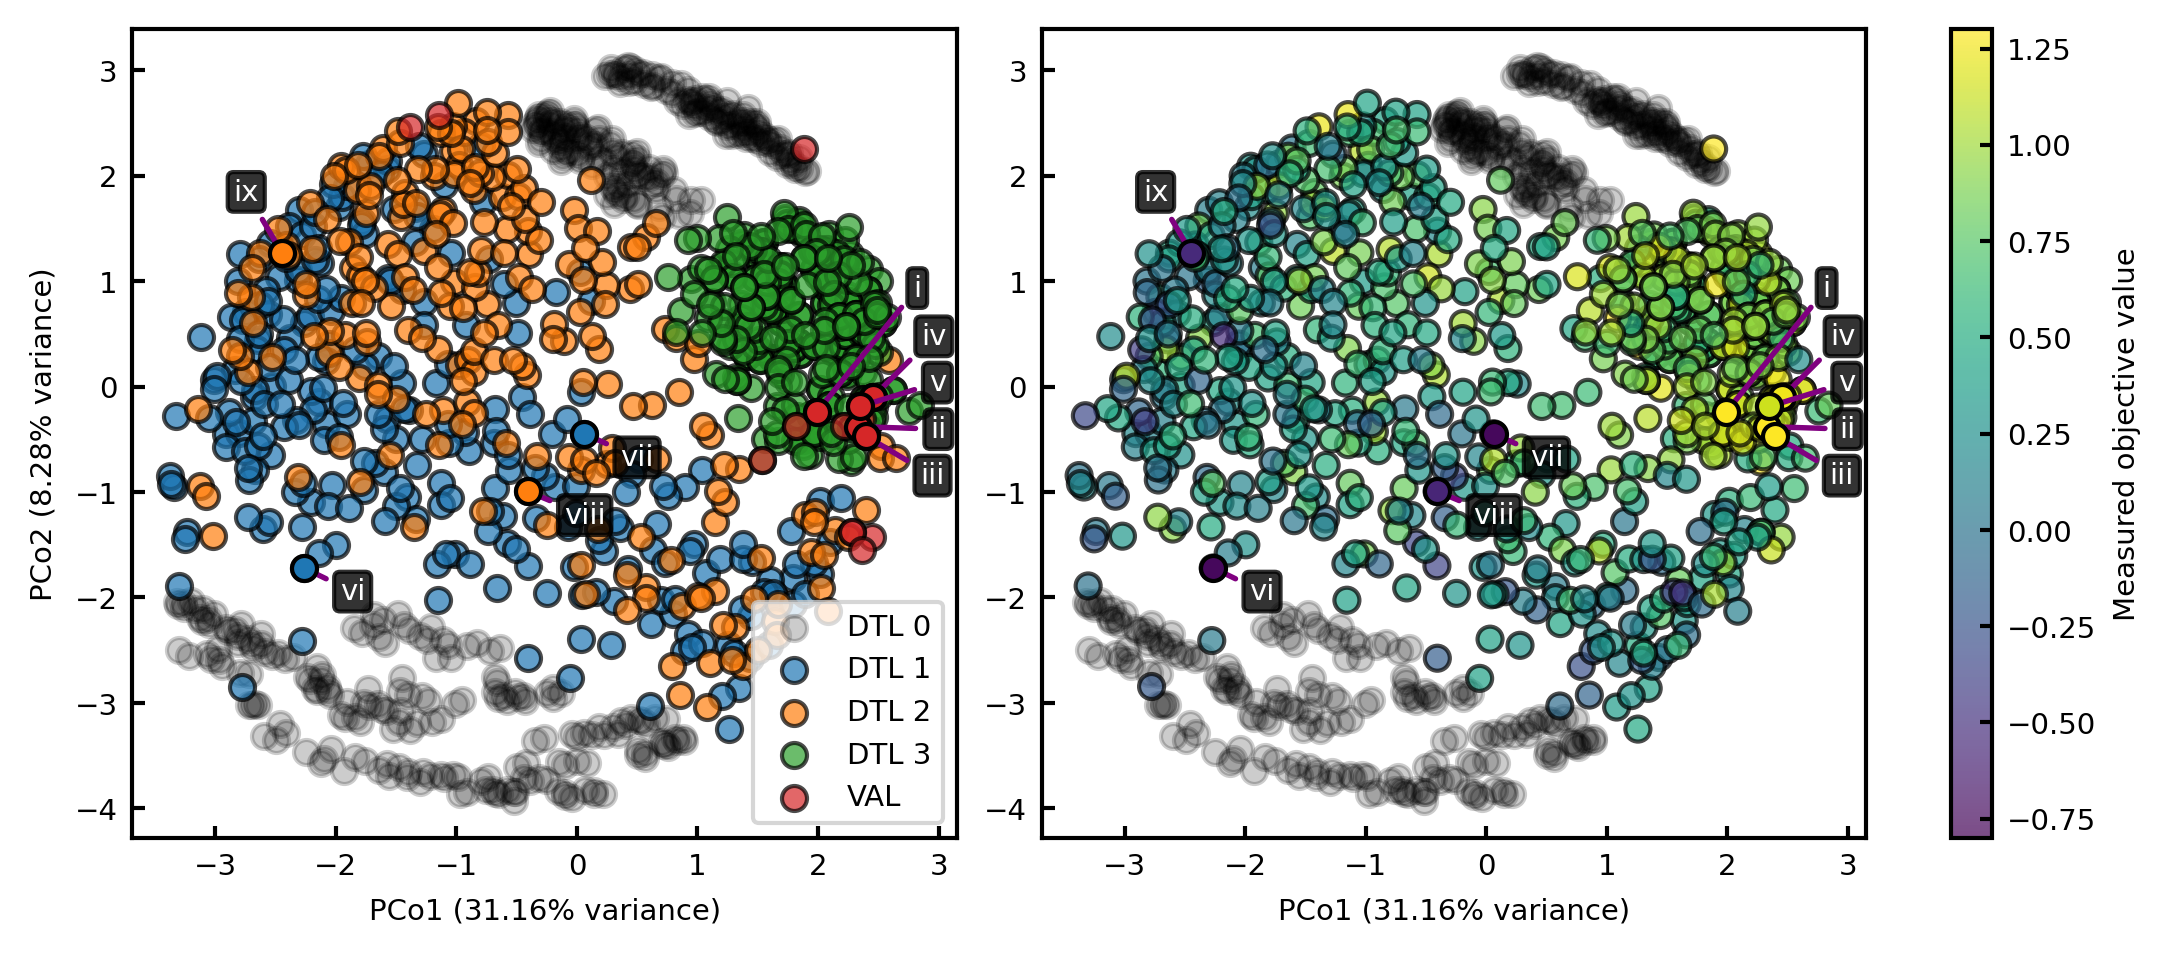

In [16]:
# plot showing traversal through design space
fig = plt.figure(figsize=(8, 3.5))

# Define a 1-row, 3-column grid, with the last column reserved for the colorbar
gs = GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.15)

# dtl progression
ax1 = fig.add_subplot(gs[0, 0])

# scatter plot of DTL 0
inds_0 = np.in1d(E, E0)
ax1.scatter(Y[inds_0, 0], Y[inds_0, 1], c='k', edgecolor='k', alpha=.2, label='DTL 0')

# scatter plot of DTL 1
inds_1 = np.in1d(E, E1)
ax1.scatter(Y[inds_1, 0], Y[inds_1, 1], c='C0', edgecolor='k', alpha=.7, label='DTL 1')

# scatter plot of DTL 2
inds_2 = np.in1d(E, E2)
ax1.scatter(Y[inds_2, 0], Y[inds_2, 1], c='C1', edgecolor='k', alpha=.7, label='DTL 2')

# scatter plot of DTL 3
inds_3 = np.in1d(E, E3)
ax1.scatter(Y[inds_3, 0], Y[inds_3, 1], c='C2', edgecolor='k', alpha=.7, label='DTL 3')

# scatter plot of DTL 3
inds_4 = np.in1d(E, E4)
ax1.scatter(Y[inds_4, 0], Y[inds_4, 1], c='C3', edgecolor='k', alpha=.7, label='VAL')

# annotate with selected points
for key, value in labels.items():
    
    # index of experiment
    inds_exp = np.in1d(E, key)
    
    # annotate label
    '''ax1.text(Y[inds_exp, 0], Y[inds_exp, 1], value, 
             fontsize=7, color='w',
             bbox=dict(facecolor='black', alpha=0.7, boxstyle='round,pad=0.2'))'''
    
    # Annotate a specific point
    ax1.annotate(value[0], 
                 xy=(Y[inds_exp, 0], Y[inds_exp, 1]), 
                 xytext=(Y[inds_exp, 0]+value[1], Y[inds_exp, 1]+value[2]),
                 arrowprops=dict(arrowstyle='-', color='purple', lw=1.3),
                 fontsize=7, zorder=1, color='w',
                 bbox=dict(facecolor='black', alpha=0.8, boxstyle='round,pad=0.2'))
    
    # prominent scatter points
    ax1.scatter(Y[inds_exp, 0], Y[inds_exp, 1], c=value[3], edgecolor='k', alpha=1, zorder=1)
    
# Add explained variance information to axis labels
ax1.legend() # (ncol=2, loc='upper left')
ax1.set_xlabel(f'PCo1 ({explained_variance_ratio[0]:.2%} variance)')
ax1.set_ylabel(f'PCo2 ({explained_variance_ratio[1]:.2%} variance)')

# objective
ax2 = fig.add_subplot(gs[0, 1])

# scatter plot of nans
inds_nan = np.isnan(y_meas)
ax2.scatter(Y[inds_nan, 0], Y[inds_nan, 1], c='k', edgecolor='k', alpha=.2)

# scatter plot of embedding 
sc = ax2.scatter(Y[:, 0], Y[:, 1], c=y_meas, vmin=-.8, vmax=1.3, cmap='viridis', edgecolor='k', alpha=.7)

# Add explained variance information to axis labels
ax2.set_xlabel(f'PCo1 ({explained_variance_ratio[0]:.2%} variance)')
# ax2.set_ylabel(f'PCo2 ({explained_variance_ratio[1]:.2%} variance)')

# annotate with selected points
for key, value in labels.items():
    
    # index of experiment
    inds_exp = np.in1d(E, key)
    
    # Annotate a specific point
    ax2.annotate(value[0], 
                 xy=(Y[inds_exp, 0], Y[inds_exp, 1]), 
                 xytext=(Y[inds_exp, 0]+value[1], Y[inds_exp, 1]+value[2]),
                 arrowprops=dict(arrowstyle='-', color='purple', lw=1.3),
                 fontsize=7, zorder=1, color='w',
                 bbox=dict(facecolor='black', alpha=0.8, boxstyle='round,pad=0.2'))
    
    # prominent scatter points
    ax2.scatter(Y[inds_exp, 0], Y[inds_exp, 1], c=y_meas[inds_exp], vmin=-.8, vmax=1.3, 
                edgecolor='k', alpha=1, zorder=1)

# Add the colorbar without affecting plot sizes
cbar = fig.colorbar(sc, cax=fig.add_subplot(gs[0, 2]))
cbar.set_label('Measured objective value')
# plt.savefig('figures/landscapes/mds_presence_absence.png', dpi=300)
# plt.savefig('figures/landscapes/mds_phylogeny_sparse.png', dpi=300)
plt.savefig('figures/landscapes/mds_phylogeny_dtl_objective.svg', dpi=300)
# plt.savefig('figures/landscapes/mds_presence_dtl_objective.png', dpi=300)
plt.show() 

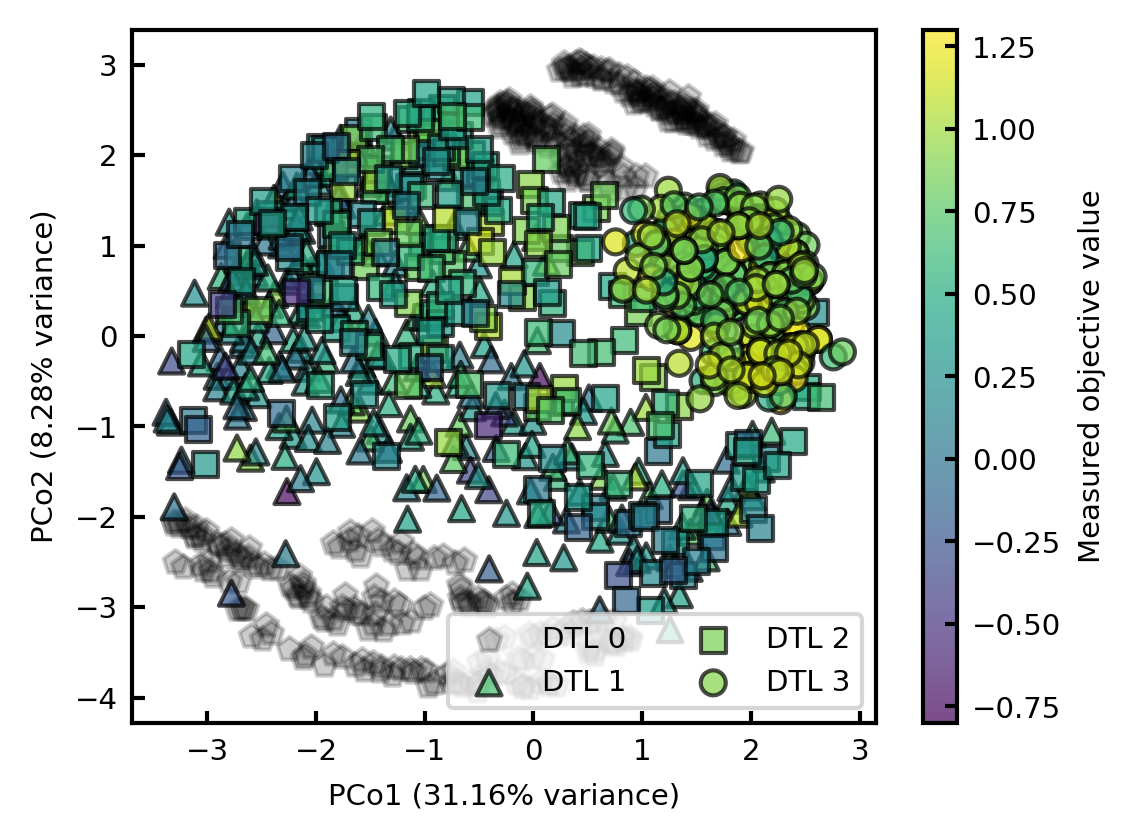

In [17]:
# plot showing traversal through design space
fig = plt.figure(figsize=(4, 3))

# scatter plot of DTL 0
inds_0 = np.in1d(E, E0)
plt.scatter(Y[inds_0, 0], Y[inds_0, 1], marker='p', c='k', edgecolor='k', alpha=.2, label='DTL 0')

# scatter plot of DTL 1
inds_1 = np.in1d(E, E1)
plt.scatter(Y[inds_1, 0], Y[inds_1, 1], marker='^', c=y_meas[inds_1], vmin=-.8, vmax=1.3, edgecolor='k', alpha=.7, label='DTL 1')

# scatter plot of DTL 2
inds_2 = np.in1d(E, E2)
plt.scatter(Y[inds_2, 0], Y[inds_2, 1], marker='s', c=y_meas[inds_2], vmin=-.8, vmax=1.3, edgecolor='k', alpha=.7, label='DTL 2')

# scatter plot of DTL 3
inds_3 = np.in1d(E, E3)
plt.scatter(Y[inds_3, 0], Y[inds_3, 1], marker='o', c=y_meas[inds_3], vmin=-.8, vmax=1.3, edgecolor='k', alpha=.7, label='DTL 3')

# annotate with selected points
for key, value in labels.items():
    
    # index of experiment
    inds_exp = np.in1d(E, key)
    
    # annotate label
    '''ax1.text(Y[inds_exp, 0], Y[inds_exp, 1], value, 
             fontsize=7, color='w',
             bbox=dict(facecolor='black', alpha=0.7, boxstyle='round,pad=0.2'))'''
    
    # Annotate a specific point
    ax1.annotate(value[0], 
                 xy=(Y[inds_exp, 0], Y[inds_exp, 1]), 
                 xytext=(Y[inds_exp, 0]+value[1], Y[inds_exp, 1]+value[2]),
                 arrowprops=dict(arrowstyle='->', color='k', lw=1.2),
                 fontsize=7, zorder=1, color='w',
                 bbox=dict(facecolor='black', alpha=0.7, boxstyle='round,pad=0.2'))
    
# Add explained variance information to axis labels
plt.legend(ncol=2, loc='lower right')
plt.xlabel(f'PCo1 ({explained_variance_ratio[0]:.2%} variance)')
plt.ylabel(f'PCo2 ({explained_variance_ratio[1]:.2%} variance)')

# Add the colorbar without affecting plot sizes
cbar = plt.colorbar()
cbar.set_label('Measured objective value')
# plt.savefig('figures/landscapes/mds_presence_absence.png', dpi=300)
# plt.savefig('figures/landscapes/mds_phylogeny_sparse.png', dpi=300)
# plt.savefig('figures/landscapes/mds_phylogeny_dtl_objective.svg', dpi=300)
# plt.savefig('figures/landscapes/mds_presence_dtl_objective.png', dpi=300)
plt.show()